In [1]:
import metaworld
from metaworld.envs import ALL_V2_ENVIRONMENTS_GOAL_OBSERVABLE 

In [2]:
import imageio.v3 as iio
import random
import numpy as np
from metaworld.policies.sawyer_faucet_close_v2_policy import SawyerFaucetCloseV2Policy as p

# Initialize the environment
# env = basketball_cls(render_mode="rgb_array", camera_name="corner")

curr_name = 'safe-stick-pull'
ml1 = metaworld.ML1(curr_name) # Construct the benchmark, sampling tasks
env = ml1.train_classes[curr_name](render_mode="rgb_array", camera_name="corner") 
# print(ml1.train_tasks)
task = random.choice(ml1.train_tasks)
# print(task)
env.set_task(task)  
obs, info = env.reset()
env._partially_observable = False
done = False
rewards = []
costs = []
qpos = []
states = []

policy = p()

# List to store frames
frames = []

i = 0
while not done:
    # action = policy.get_action(obs)
    # action = env.action_space.sample()
    action = np.array([0, 0, 0, 0])
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()  # Capture frame as RGB array
    frames.append(np.flipud(frame))  # Add frame to the list
    done = terminated or truncated or (int(info['success']) == 1) or i > 25
    i += 1
    rewards.append(reward)
    costs.append(info['unscaled_cost'])
    qpos.append(env.data.qpos.copy())
    states.append(obs[18:21])

# Save the video
iio.imwrite("basketball_simulation.mp4", frames, fps=30)  # Adjust fps if necessary

env.close()


In [3]:
import matplotlib.pyplot as plt
plt.plot(np.array(states), alpha=0.5, linestyle=':')


NameError: name 'plt' is not defined

In [ ]:
print(sum(rewards))
print(sum(costs))

0.003791449987326895
0.0


Text(0.5, 0, 'Simulation Timestep')

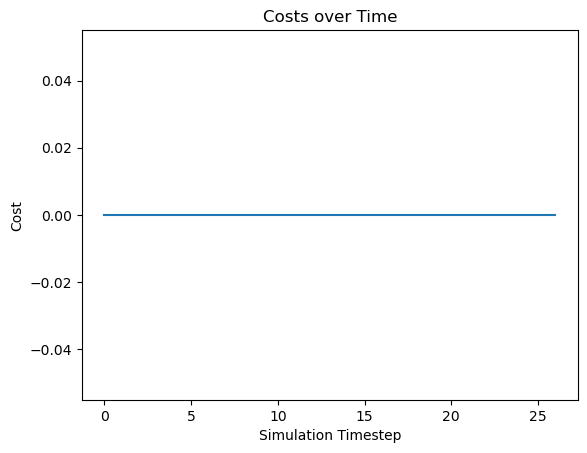

In [ ]:
import matplotlib.pyplot as plt

plt.title("Costs over Time")
plt.plot(costs)
plt.ylabel("Cost")
plt.xlabel("Simulation Timestep")